In [7]:
from ase import Atoms
from ase.io import Trajectory
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from flonacomldft.dft_utils import *
import os
from pathlib import Path
from ase.io import read

from sympy import minimum
sys.path.insert(0,str(Path.home())+'/utils/python')
from plotter2 import Plotter

In [2]:
if os.path.isdir('/mnt/home/amolina/ceph/database'):
   ceph_home = '/mnt/home/amolina/ceph/database'
elif os.path.isdir('/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/'):
   ceph_home = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft/'
elif os.path.isdir('/home/anacristina/ml_dft_project/database/'):
    ceph_home = '/home/anacristina/ml_dft_project/database/'
elif os.path.isdir('/home/amolina/ml_dft_project/database/'):
    ceph_home = '/home/amolina/ml_dft_project/database/'
else:
   raise RuntimeError('Data path not understood')

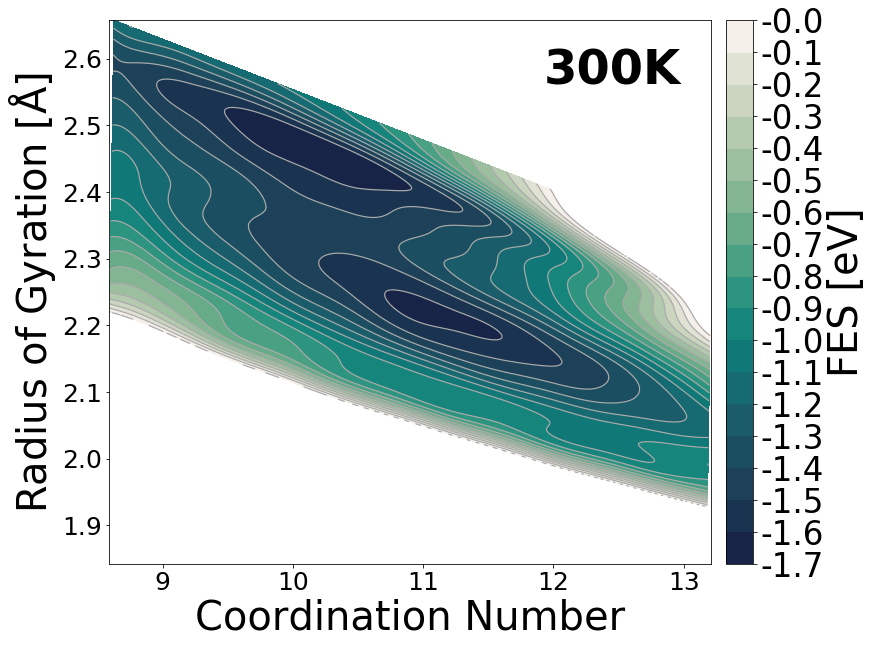

In [3]:
plotting = Plotter(400, 'Ag6')
plotting.readfile(ceph_home + 'unrotated_300.txt')
ax = plotting.plot_fes(0.1, 300, delta2=0.1, shift=1)

In [4]:
minimum_fd = read(ceph_home + 'ag6_is1_fd.xyz')
minimum_lcao_pv = read(ceph_home + 'ag6_is1_lcao.xyz')
minimum_lcao_df = read('ag6_is1_default.xyz')

In [5]:
c_min_fd, r_min_fd = C(minimum_fd), R(minimum_fd)
c_min_lcao_pv, r_min_lcao_pv = C(minimum_lcao_pv), R(minimum_lcao_pv)
c_min_lcao_df, r_min_lcao_df = C(minimum_lcao_df), R(minimum_lcao_df)

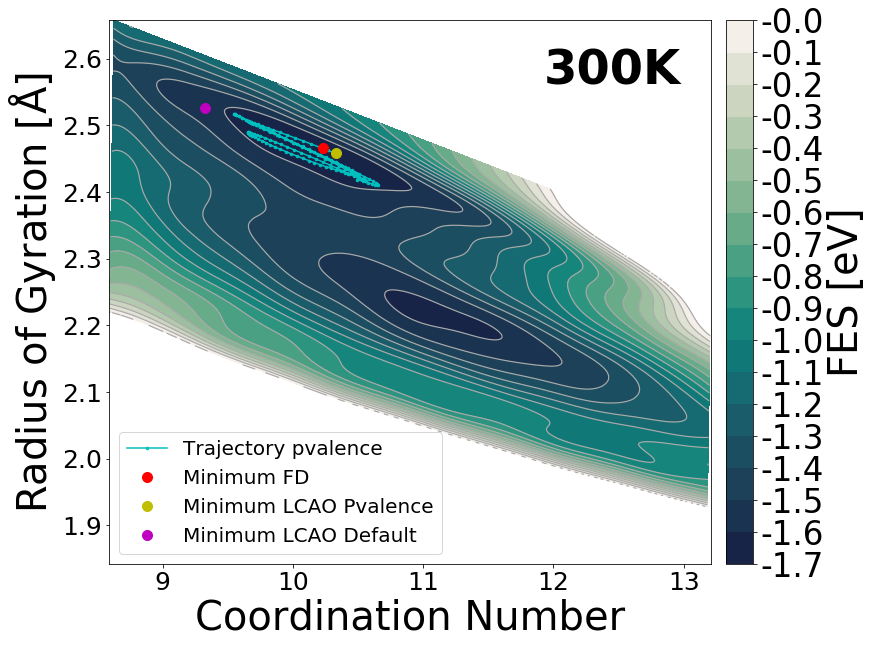

In [6]:
from ase.io import Trajectory
traj = Trajectory(ceph_home + 'ag6_is1_lcao.traj')
c_traj = [] 
r_traj = []
for traj_ in traj[:160]:
    c_, r_ = C(traj_), R(traj_)
    c_traj.append(c_)
    r_traj.append(r_)

ax = plotting.plot_fes(0.1, 300, delta2=0.1, shift=1)
ax.plot(c_traj, r_traj, 'c.-', markersize=5, label='Trajectory pvalence')
ax.plot(c_min_fd, r_min_fd, 'ro', markersize=10, label='Minimum FD')
ax.plot(c_min_lcao_pv, r_min_lcao_pv, 'yo', markersize=10, label='Minimum LCAO Pvalence')
ax.plot(c_min_lcao_df, r_min_lcao_df, 'mo', markersize=10, label='Minimum LCAO Default')
ax.legend(loc='lower left', fontsize=20)